> ## Atividade Prática: Classificação com Support Vector Machines (SVM)
> 
> **Aluno:** Victor Augusto Viana Fernandes
>
> **Turma:** 6A - manhã
> 
> **Objetivo:** Este notebook tem como objetivo realizar a análise exploratória do conjunto de dados Breast Cancer Wisconsin (Diagnostic) e desenvolver um modelo de classificação utilizando o algoritmo SVM.

## Importação das bibliotecas
Primeiro, importa as bibliotecas necessárias para manipulação/visualização de dados e as ferramentas de Machine Learning do scikit-learn para construção e avaliação do modelo SVM.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,8)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("bibliotecas importadas!")

bibliotecas importadas!


## Carregamento dos dados do dataset¶
*As características foram computadas a partir de imagens digitalizadas de biópsias por aspiração com agulha fina (FNA) de massas mamárias e descrevem aspectos dos núcleos celulares presentes na imagem. O objetivo é classificar os tumores em Malignos (M) ou Benignos (B).*

In [2]:
# lê o arquivo com pandas
df = pd.read_csv("/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv")

In [3]:
df.iloc[:10]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


## Análise exploratória de dados (EDA)
*Antes de treinar o modelo, verifica como é a estrutura, os tipos de dados/colunas presentes, se tem valor faltando e possíveis valores nulos no dataset.*

In [4]:
print("Dimensão do dataset:", df.shape)

# exibe os tipos de dados presentes no df
print("\nInformações estruturais:")
df.info()

# exibe resumo estatístico
print("\nResumo estatístico:")
display(df.describe())

Dimensão do dataset: (569, 33)

Informações estruturais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se             

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


*Após a análise dos dados brutos, foi feita a limpeza de valores nulos e não essenciais, além de acrescentar uma coluna para a variável-alvo.*

In [5]:
df_tratado = df.drop(["id", "Unnamed: 32"], axis=1)
df_tratado["diagnosis_id"] = pd.factorize(df_tratado["diagnosis"])[0]
df_tratado.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_id
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


*Análise da proporção dos rótulos:*

In [6]:
print("Proporção entre os rótulos Benignos e Malignos")
print(df_tratado["diagnosis"].value_counts())
print("\nProporção entre os rótulos Benignos e Malignos (normalizado)")
print(df_tratado["diagnosis"].value_counts(normalize=True))

Proporção entre os rótulos Benignos e Malignos
diagnosis
B    357
M    212
Name: count, dtype: int64

Proporção entre os rótulos Benignos e Malignos (normalizado)
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


*Análise da correlação entre os dados:*

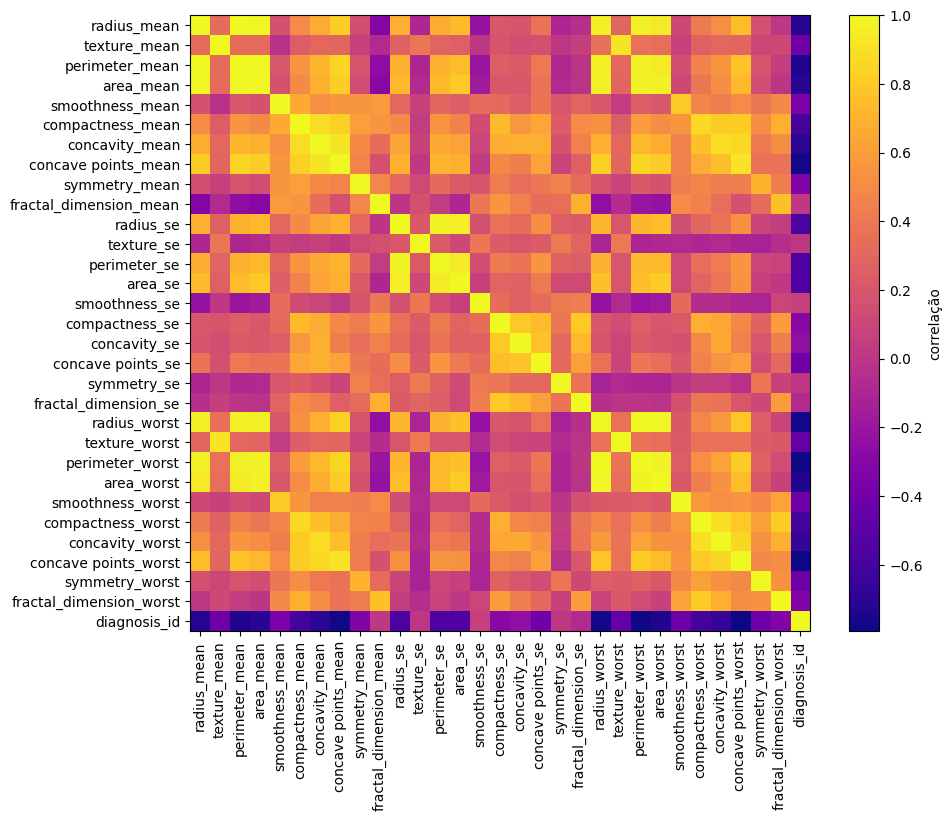

In [7]:
plt.figure()
correlacao = df_tratado.drop(["diagnosis"],axis=1).corr()
plt.imshow(correlacao, cmap="plasma", aspect="auto")
plt.colorbar(label="correlação")

plt.xticks(range(correlacao.shape[1]),correlacao.columns, rotation=90)
plt.yticks(range(correlacao.shape[1]),labels=correlacao.columns)

plt.show()


*Com base nas maiores correlações, foi feito um gráfico de dispersão para exploração visual dos dados:*

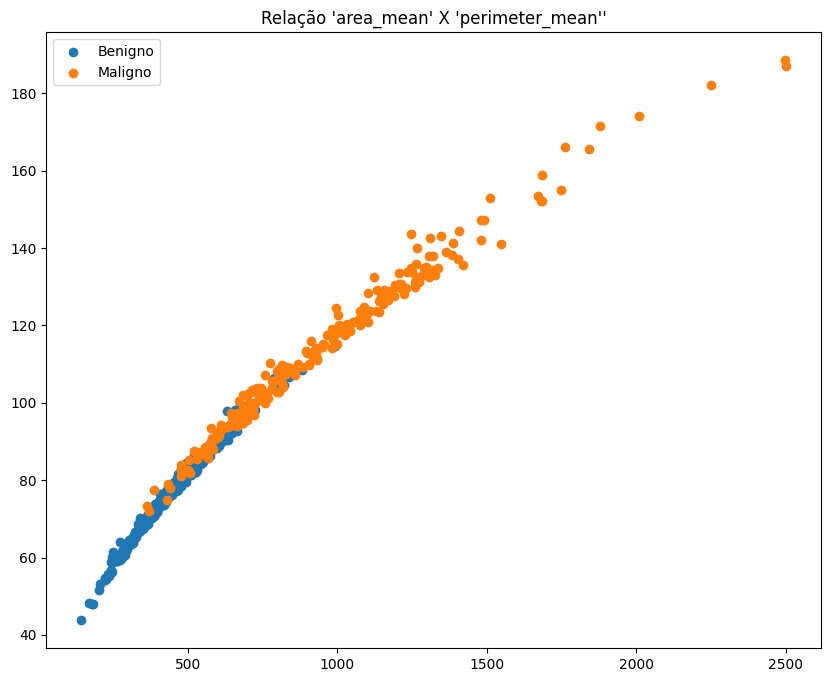

In [8]:
plt.figure()

_benignos = df_tratado[df_tratado["diagnosis_id"]==1]
_malignos = df_tratado[df_tratado["diagnosis_id"]==0]

plt.scatter(_benignos["area_mean"],_benignos["perimeter_mean"], label="Benigno")
plt.scatter(_malignos["area_mean"],_malignos["perimeter_mean"], label="Maligno")

plt.legend()

plt.title("Relação 'area_mean' X 'perimeter_mean''")
plt.show()


## Divisão dos dados em treino e teste¶

In [9]:
X = df_tratado.copy().drop(["diagnosis_id","diagnosis"], axis=1)
y = df_tratado["diagnosis_id"].copy()

In [10]:
# exibe
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diagnosis_id, dtype: int64

*São separados 80% para treino e 20% para teste, com stratify=y para manter a proporção das 3 espécies nos dois grupos:*

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

## Treino SVM linear com Pipeline
*É criado um Pipeline que padroniza os dados e já treina o SVC linear em seguida. Usar Pipeline evita erro de vazar informação do teste para o treino.*

In [13]:
# pipeline com svc linear
pipeline_linear = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=10, random_state=42))
    ]
)
pipeline_linear.fit(X_train, y_train)
y_pred = pipeline_linear.predict(X_test)

print(f"Acuracia do SVM linear: {accuracy_score(y_test, y_pred)*100:.2f}%")
# outras métricas
print(f"\n\nRelatório de classificação:\n{classification_report(y_test, y_pred)}")
print(f"\n\n Média de precisão com 'cross_val_score'(cv=10): {np.array(cross_val_score(pipeline_linear,X,y, cv=10)).mean():.2f}\n")

Acuracia do SVM linear: 98.25%


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



 Média de precisão com 'cross_val_score'(cv=10): 0.97



## Matriz de Confusão do SVM linear¶
*A matriz mostra os acertos (na diagonal) e os erros (fora dela) por espécie.*

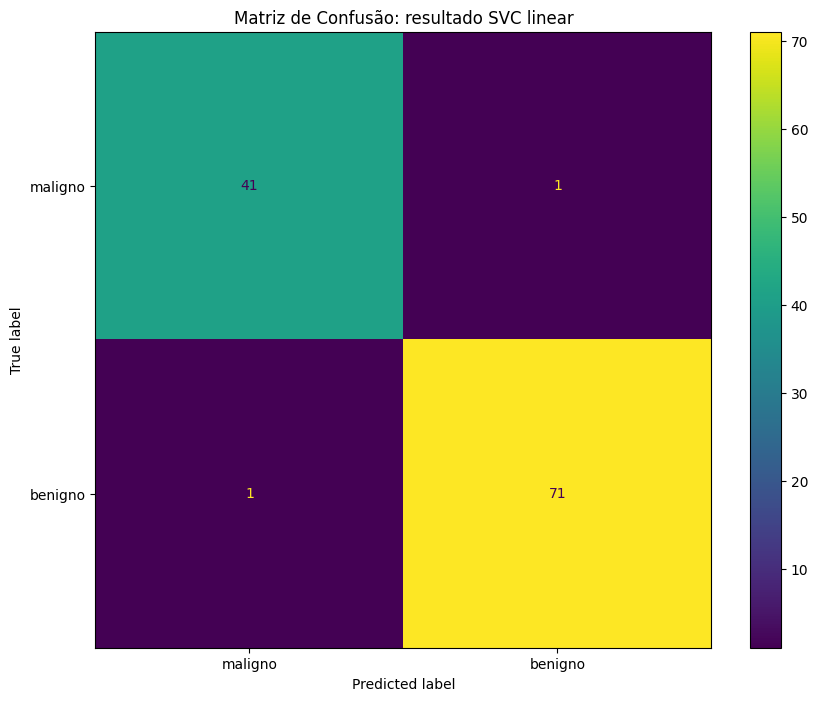

In [14]:
cm = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=["maligno","benigno"])
cm_display.plot()
plt.title("Matriz de Confusão: resultado SVC linear")
plt.show()

## Treino SVM não linear com kernel RBF
*Agora, o teste será com kernel RBF, que permite fronteiras mais curvas/complexas, para ver se melhora o resultado ou não.*

In [15]:
# pipeline com svc rbf
pipeline_rbf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ]
)
pipeline_rbf.fit(X_train, y_train)
y_pred = pipeline_rbf.predict(X_test)

print(f"accuracy score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"\n\nRelatório de classificação:\n{classification_report(y_test, y_pred)}")
print(f"\n\n Média de precisão com 'cross_val_score'(cv=10): {np.array(cross_val_score(pipeline_rbf,X,y, cv=10)).mean():.2f}\n")

accuracy score: 98.25%


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



 Média de precisão com 'cross_val_score'(cv=10): 0.98



## Matriz de Confusão do SVM não linear com kernel RBF

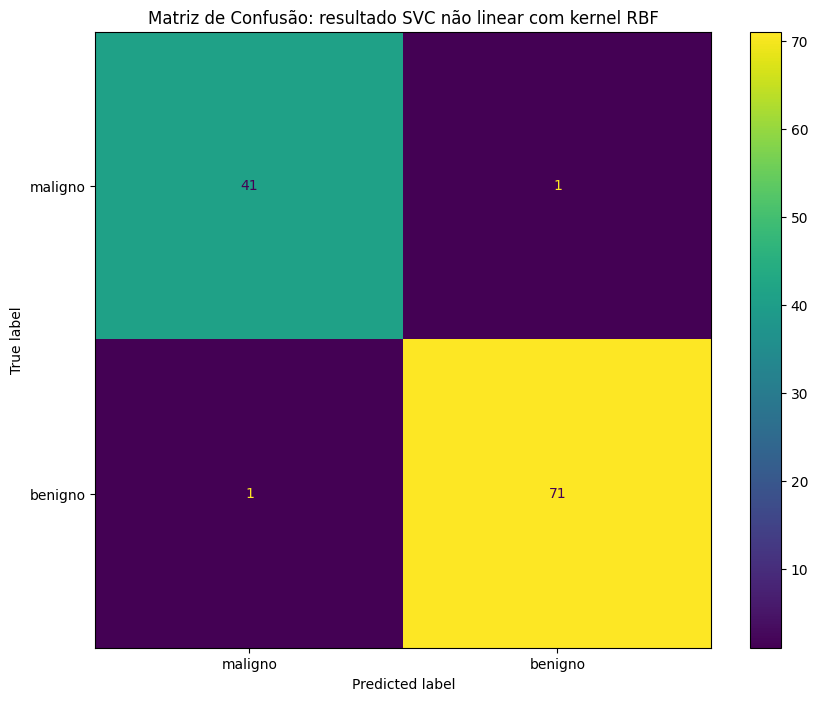

In [16]:
cm = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=["maligno","benigno"])
cm_display.plot()
plt.title("Matriz de Confusão: resultado SVC não linear com kernel RBF")
plt.show()